In [216]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

In [217]:
df=pd.read_csv(r'C:/Machine learning/heartdisease/heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [218]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [219]:
print('Unique_values_in_all_colums')
for c in df.columns:
    print(f'{c}: {df[c].unique()}')

Unique_values_in_all_colums
Age: [40 49 37 48 54 39 45 58 42 38 43 60 36 44 53 52 51 56 41 32 65 35 59 50
 47 31 46 57 55 63 66 34 33 61 29 62 28 30 74 68 72 64 69 67 73 70 77 75
 76 71]
Sex: <StringArray>
['M', 'F']
Length: 2, dtype: str
ChestPainType: <StringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str
RestingBP: [140 160 130 138 150 120 110 136 115 100 124 113 125 145 112 132 118 170
 142 190 135 180 108 155 128 106  92 200 122  98 105 133  95  80 137 185
 165 126 152 116   0 144 154 134 104 139 131 141 178 146 158 123 102  96
 143 172 156 114 127 101 174  94 148 117 192 129 164]
Cholesterol: [289 180 283 214 195 339 237 208 207 284 211 164 204 234 273 196 201 248
 267 223 184 288 215 209 260 468 188 518 167 224 172 186 254 306 250 177
 227 230 294 264 259 175 318 216 340 233 205 245 194 270 213 365 342 253
 277 202 297 225 246 412 265 182 218 268 163 529 100 206 238 139 263 291
 229 307 210 329 147  85 269 275 179 392 466 129 241 255 276 282 338 160
 156 272 240 393 161

In [220]:
df.duplicated().sum()

np.int64(0)

In [221]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


<Axes: >

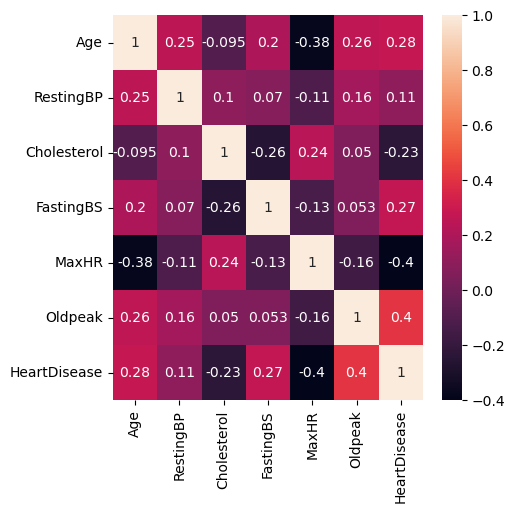

In [222]:
plt.figure(figsize=(5,5))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [223]:
split=StratifiedShuffleSplit(n_splits=1,test_size=0.2)
for train_indices, test_indices in split.split(df,df["HeartDisease"]):
    strat_train=df.iloc[train_indices]
    strat_test=df.iloc[test_indices]

In [224]:
(strat_train["HeartDisease"]).value_counts()/(len(strat_train))

HeartDisease
1    0.553134
0    0.446866
Name: count, dtype: float64

In [225]:
x_train=strat_train.drop(columns=['HeartDisease'])
y_train=strat_train['HeartDisease'].copy()
x_test=strat_test.drop(columns=['HeartDisease'])
y_test=strat_test['HeartDisease'].copy()

In [226]:
scalar=StandardScaler()
add=SimpleImputer(strategy='median')
num_pipeline=Pipeline([
    ('imputer',add),
    ('scale',scalar)
])

In [227]:
num_attribs=x_train.select_dtypes(include=['int64','float64']).columns
cat_attribs=x_train.select_dtypes(exclude=['int64','float64']).columns
pipeline=ColumnTransformer([
    ('num',num_pipeline,num_attribs,),
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_attribs)
])

In [228]:
x_train_tr=pipeline.fit_transform(x_train)
x_test_tr=pipeline.transform(x_test)

In [247]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
lr=LogisticRegression(max_iter=1000,random_state=30)

In [248]:
#logistic Regression
lr.fit(x_train_tr,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",30
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [249]:
y_pred_lr=lr.predict(x_test_tr)

In [250]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss
from sklearn.metrics import classification_report

In [251]:
y_proba_lr=lr.predict_proba(x_test_tr)[:,1]
cm_lr=confusion_matrix(y_test,y_pred_lr)

In [252]:
print(confusion_matrix(y_test,y_pred_lr))
print(accuracy_score(y_test,y_pred_lr))
print(log_loss(y_test,y_proba_lr))
print(classification_report(y_test,y_pred_lr,target_names=["HeartDisease",'NOHeartDisease']))

[[69 13]
 [11 91]]
0.8695652173913043
0.3656039915431189
                precision    recall  f1-score   support

  HeartDisease       0.86      0.84      0.85        82
NOHeartDisease       0.88      0.89      0.88       102

      accuracy                           0.87       184
     macro avg       0.87      0.87      0.87       184
  weighted avg       0.87      0.87      0.87       184



<Figure size 100x100 with 0 Axes>

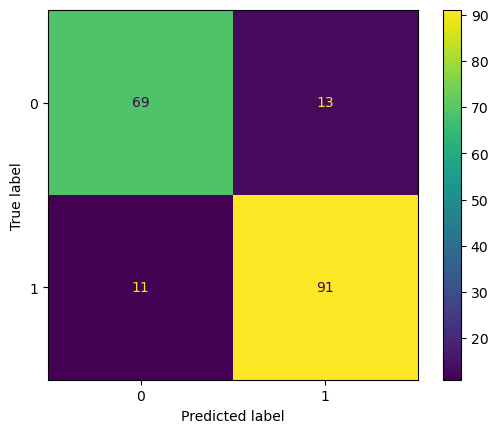

In [253]:
plt.figure(figsize=(1,1))
ConfusionMatrixDisplay(cm_lr,display_labels=lr.classes_).plot()
plt.show()

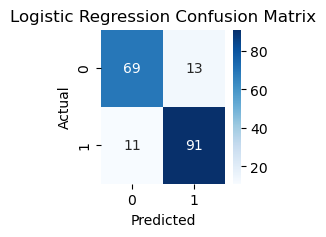

In [254]:
plt.figure(figsize=(2,2))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lr.classes_,
    yticklabels=lr.classes_
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [255]:
from sklearn.metrics import roc_curve
# 1. Get predicted probabilities for the positive class (Class 1)
# y_scores will be an array of floats between 0.0 and 1.0
# 2. Compute ROC curve metrics and all potential thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)
# 3. Apply a mathematical definition of "optimal"
# Youden's J Statistic = True Positive Rate - False Positive Rate
j_scores = tpr - fpr
# 4. Locate the index of the highest score
best_index = np.argmax(j_scores)
# 5. Extract the optimal threshold value
optimal_threshold = thresholds[best_index]
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Resulting TPR (Recall): {tpr[best_index]:.4f}")
print(f"Resulting FPR: {fpr[best_index]:.4f}")
# 6. Apply the threshold to make final predictions
final_predictions = (y_proba_lr >= optimal_threshold).astype(int)


Optimal Threshold: 0.5334
Resulting TPR (Recall): 0.8824
Resulting FPR: 0.1341


In [256]:
# 1. Define your strict target recall (e.g., 95%)
target_recall = 0.95
# 2. Get your curve arrays (thresholds are sorted in descending order)
# 3. Find the first index where TPR meets or exceeds your target
# Since thresholds decrease, this finds the highest threshold that works
recall_index = np.argmax(tpr >= target_recall)
# 4. Extract the tuned threshold
high_recall_threshold = thresholds[recall_index]
print(f"Tuned Threshold for {target_recall*100}% Recall: {high_recall_threshold:.4f}")
print(f"Actual Recall: {tpr[recall_index]:.4f} | Resulting FPR: {fpr[recall_index]:.4f}")

Tuned Threshold for 95.0% Recall: 0.2586
Actual Recall: 0.9608 | Resulting FPR: 0.3780


In [262]:
from sklearn.metrics import precision_recall_curve
# 1. Define your strict target precision (e.g., 90%)
target_precision = 0.90
# 2. Get Precision-Recall curve arrays
# Note: precision_recall_curve returns thresholds in ascending order
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, y_proba_lr)
print("Maximum Precision achieved by model:", precision_lr[:-1].max())
# 3. Find all indices where precision meets your target
valid_indices = np.where(precision_lr[:-1] >= target_precision)[0]
# 4. Pick the first one (gives the lowest threshold to maximize recall)
precision_index = valid_indices[0]
high_precision_threshold = thresholds_lr[precision_index]
print(f"Tuned Threshold for {target_precision*100}% Precision: {high_precision_threshold:.4f}")
print(f"Actual Precision: {precision_lr[precision_index]:.4f} | Resulting Recall: {recall_lr[precision_index]:.4f}")


Maximum Precision achieved by model: 1.0
Tuned Threshold for 90.0% Precision: 0.7443
Actual Precision: 0.9070 | Resulting Recall: 0.7647


In [263]:
# Get probabilities on your hold-out test set
optimal_testprobab_lr = lr.predict_proba(x_test_tr)[:, 1]
# Apply the custom threshold
tuned_predictions_lr = (optimal_testprobab_lr >= high_precision_threshold).astype(int)
# Pass the custom predictions to your evaluation metrics
print("--- Confusion Matrix with Tuned Threshold ---")
print(confusion_matrix(y_test, tuned_predictions_lr))
print("\n--- Classification Report with Tuned Threshold ---")
print(classification_report(y_test, tuned_predictions_lr))

--- Confusion Matrix with Tuned Threshold ---
[[74  8]
 [24 78]]

--- Classification Report with Tuned Threshold ---
              precision    recall  f1-score   support

           0       0.76      0.90      0.82        82
           1       0.91      0.76      0.83       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.84      0.83      0.83       184



In [264]:
# Get probabilities on your hold-out test set
optimal_testprobab_lr_recall = lr.predict_proba(x_test_tr)[:, 1]
# Apply the custom threshold
tuned_predictions_lr_recall = (optimal_testprobab_lr_recall >= high_recall_threshold).astype(int)
# Pass the custom predictions to your evaluation metrics
print("--- Confusion Matrix with Tuned Threshold ---")
print(confusion_matrix(y_test, tuned_predictions_lr_recall))
print("\n--- Classification Report with Tuned Threshold ---")
print(classification_report(y_test, tuned_predictions_lr_recall))

--- Confusion Matrix with Tuned Threshold ---
[[51 31]
 [ 4 98]]

--- Classification Report with Tuned Threshold ---
              precision    recall  f1-score   support

           0       0.93      0.62      0.74        82
           1       0.76      0.96      0.85       102

    accuracy                           0.81       184
   macro avg       0.84      0.79      0.80       184
weighted avg       0.83      0.81      0.80       184



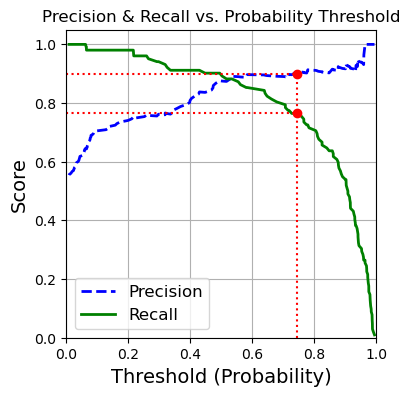

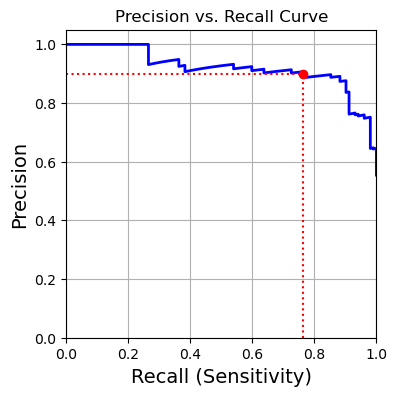

In [265]:
# --- 1. Plot Precision and Recall vs. Threshold ---
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.legend(loc="lower left", fontsize=12)
    plt.xlabel("Threshold (Probability)", fontsize=14)
    plt.ylabel("Score", fontsize=14)
    plt.grid(True)
    plt.axis([0, 1, 0, 1.05])  # FIXED: Probability ranges from 0 to 1

# Find the exact point where precision hits or exceeds 90%
idx_90_precision = np.argmax(precision_lr >= 0.90)
recall_90_precision = recall_lr[idx_90_precision]
threshold_90_precision = thresholds_lr[idx_90_precision]

plt.figure(figsize=(4, 4))                                                                  
plot_precision_recall_vs_threshold(precision_lr, recall_lr, thresholds_lr)

# Draw red targeting lines mapping to the 0 to 1 domain
plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], "r:")                 
plt.plot([0, threshold_90_precision], [0.9, 0.9], "r:")                                
plt.plot([0, threshold_90_precision], [recall_90_precision, recall_90_precision], "r:")
plt.plot([threshold_90_precision], [0.9], "ro")                                             
plt.plot([threshold_90_precision], [recall_90_precision], "ro")                             
plt.title("Precision & Recall vs. Probability Threshold")
plt.show()


# --- 2. Plot Precision vs. Recall ---

def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall (Sensitivity)", fontsize=14)
    plt.ylabel("Precision", fontsize=14)
    plt.axis([0, 1, 0, 1.05])
    plt.grid(True)

plt.figure(figsize=(4,4))
plot_precision_vs_recall(precision_lr, recall_lr)

# Draw red indicator lines tracking 90% precision point
plt.plot([recall_90_precision, recall_90_precision], [0., 0.9], "r:")
plt.plot([0.0, recall_90_precision], [0.9, 0.9], "r:")
plt.plot([recall_90_precision], [0.9], "ro")
plt.title("Precision vs. Recall Curve")
plt.show()


In [266]:
rf=RandomForestClassifier(random_state=42)

In [267]:
from sklearn.model_selection import cross_val_score

In [268]:
cross_val_score(RandomForestClassifier(criterion='entropy',max_depth=20),x_train_tr,y_train,cv=8,)

array([0.90217391, 0.79347826, 0.83695652, 0.86956522, 0.85869565,
       0.90217391, 0.84615385, 0.89010989])

In [269]:
cross_val_score(RandomForestClassifier(criterion='entropy',max_depth=60),x_train_tr,y_train,cv=10,)

array([0.91891892, 0.77027027, 0.87837838, 0.83783784, 0.89041096,
       0.83561644, 0.93150685, 0.83561644, 0.87671233, 0.90410959])

In [270]:
param=[{'n_estimators' : [100,150,200],'max_depth':[10,20,30,40,50]}]
clf=GridSearchCV(rf,param,cv=10,refit=True)

In [271]:
clf.fit(x_train_tr,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_depth': [10, 20, ...], 'n_estimators': [100, 150, ...]}]"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of inform

In [272]:
df=pd.DataFrame(clf.cv_results_)

In [273]:
df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.226896,0.013319,0.011852,0.006531,10,100,"{'max_depth': 10, 'n_estimators': 100}",0.918919,0.824324,0.864865,0.824324,0.890411,0.863014,0.917808,0.835616,0.876712,0.904110,0.872010,0.034196,3
1,0.339532,0.028667,0.016851,0.004880,10,150,"{'max_depth': 10, 'n_estimators': 150}",0.918919,0.824324,0.864865,0.824324,0.917808,0.849315,0.931507,0.808219,0.890411,0.917808,0.874750,0.044025,2
2,0.432586,0.043584,0.020825,0.006281,10,200,"{'max_depth': 10, 'n_estimators': 200}",0.918919,0.810811,0.878378,0.837838,0.890411,0.863014,0.931507,0.821918,0.890411,0.917808,0.876101,0.039864,1
3,0.165096,0.016302,0.012820,0.005459,20,100,"{'max_depth': 20, 'n_estimators': 100}",0.905405,0.824324,0.878378,0.837838,0.876712,0.835616,0.917808,0.808219,0.890411,0.904110,0.867882,0.036482,12
4,0.253624,0.012675,0.013922,0.002606,20,150,"{'max_depth': 20, 'n_estimators': 150}",0.918919,0.797297,0.851351,0.837838,0.890411,0.835616,0.931507,0.821918,0.904110,0.917808,0.870678,0.044944,4
5,0.354654,0.033979,0.020512,0.005177,20,200,"{'max_depth': 20, 'n_estimators': 200}",0.918919,0.797297,0.864865,0.837838,0.876712,0.849315,0.931507,0.821918,0.890411,0.917808,0.870659,0.042433,8
6,0.173126,0.009302,0.009388,0.005470,30,100,"{'max_depth': 30, 'n_estimators': 100}",0.905405,0.824324,0.878378,0.837838,0.876712,0.835616,0.917808,0.808219,0.890411,0.904110,0.867882,0.036482,12
7,0.259442,0.019376,0.016171,0.004224,30,150,"{'max_depth': 30, 'n_estimators': 150}",0.918919,0.797297,0.851351,0.837838,0.890411,0.835616,0.931507,0.821918,0.904110,0.917808,0.870678,0.044944,4
8,0.364991,0.022395,0.021160,0.004392,30,200,"{'max_depth': 30, 'n_estimators': 200}",0.918919,0.797297,0.864865,0.837838,0.876712,0.849315,0.931507,0.821918,0.890411,0.917808,0.870659,0.042433,8
9,0.178161,0.015479,0.012431,0.002715,40,100,"{'max_depth': 40, 'n_estimators': 100}",0.905405,0.824324,0.878378,0.837838,0.876712,0.835616,0.917808,0.808219,0.890411,0.904110,0.867882,0.036482,12


In [274]:
clf.best_params_

{'max_depth': 10, 'n_estimators': 200}

In [275]:
y_pred_rf=clf.predict(x_test_tr)

In [276]:
y_proba_rf=clf.predict_proba(x_test_tr)[:,1]
cm_rf=confusion_matrix(y_test,y_pred_rf)

In [277]:
print(confusion_matrix(y_test,y_pred_rf))
print(accuracy_score(y_test,y_pred_rf))
print(log_loss(y_test,y_proba_rf))
print(classification_report(y_test,y_pred_rf,target_names=["HeartDisease",'NOHeartDisease']))

[[63 19]
 [ 6 96]]
0.8641304347826086
0.38815612102601826
                precision    recall  f1-score   support

  HeartDisease       0.91      0.77      0.83        82
NOHeartDisease       0.83      0.94      0.88       102

      accuracy                           0.86       184
     macro avg       0.87      0.85      0.86       184
  weighted avg       0.87      0.86      0.86       184



In [278]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import time

In [279]:
gbc=GradientBoostingClassifier()
start=time.time()

In [280]:
print("GradientBoosting Classifier : \t" , cross_val_score(gbc , x_train_tr , y_train , cv = 10 , scoring = "accuracy").mean()*100 , "% , time taken in cross validation = ", time.time() - start )

GradientBoosting Classifier : 	 86.66234727878562 % , time taken in cross validation =  1.730835199356079


In [281]:
param_gbc=[{'n_estimators' : [100,150,200],'max_depth':[5,10,15,20]}]
gbc_=GridSearchCV(gbc,param_gbc,cv=10,refit=True)

In [282]:
gbc_.fit(x_train_tr,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_depth': [5, 10, ...], 'n_estimators': [100, 150, ...]}]"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informati

In [283]:
df_gbc=pd.DataFrame(gbc_.cv_results_)
gbc_.best_params_

{'max_depth': 5, 'n_estimators': 200}

In [284]:
y_pred_gbc=gbc_.predict(x_test_tr)

In [285]:
y_proba_gbc=gbc_.predict_proba(x_test_tr)[:,1]
cm_gbc=confusion_matrix(y_test,y_pred_gbc)

In [286]:
print(confusion_matrix(y_test,y_pred_gbc))
print(accuracy_score(y_test,y_pred_gbc))
print(log_loss(y_test,y_proba_gbc))
print(classification_report(y_test,y_pred_gbc,target_names=["HeartDisease",'NOHeartDisease']))

[[63 19]
 [10 92]]
0.842391304347826
0.517151077675446
                precision    recall  f1-score   support

  HeartDisease       0.86      0.77      0.81        82
NOHeartDisease       0.83      0.90      0.86       102

      accuracy                           0.84       184
     macro avg       0.85      0.84      0.84       184
  weighted avg       0.84      0.84      0.84       184



In [287]:
print(accuracy_score(y_test,y_pred_lr))
print(accuracy_score(y_test,y_pred_rf))
print(accuracy_score(y_test,y_pred_gbc))

0.8695652173913043
0.8641304347826086
0.842391304347826
